# Test en Machine Learning
## Prétraitement de données

### Etape 1 : Faites les importations des bibliothèques nécessaires

In [114]:
import pandas as pd
import numpy as np
import math
import seaborn as sns
import matplotlib.pyplot as plt
import warnings 
warnings.filterwarnings('ignore')

### Etape 2 : Importer les données du fichier "dataset_ProjetML_2026.csv"

In [115]:
df = pd.read_csv("dataset_ProjetML_2026.csv", sep =',',  header =0)
print(type(df))

<class 'pandas.core.frame.DataFrame'>


### Etape 3 : Afficher un échontillon du dataframe

In [116]:
df.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
0,16.708780,70.940977,0.0,1.0,1.0,0.835439,Papier,NaN,Lot de papier récupéré dans un site non rensei...
1,47.277476,64.702925,0.0,NaN,3.0,4.727748,Plastique,Usine_A,"Lot plastique à l'Usine A. Volume 64.7 L, poid..."
2,NaN,317.415183,0.0,NaN,9.0,4.211790,Verre,Usine_B,Bris de verre ou contenants en provenance de l...
3,NaN,21.474391,0.0,NaN,1.0,0.442067,Papier,Centre_Tri,Feuilles et cartons collectés au Centre de Tri...
4,NaN,59.462176,0.0,1.0,NaN,0.723004,Papier,Usine_B,Déchet de type papier identifié à l'Usine B. V...


### Etape 4 : Afficher toutes les variables du dataset et leurs types respectifs

In [117]:
df.dtypes

Poids               float64
Volume              float64
Conductivite        float64
Opacite             float64
Rigidite            float64
Prix_Revente        float64
Categorie            object
Source               object
Rapport_Collecte     object
dtype: object

### Etape 5 : Afficher la description du dataset

In [118]:
df.describe()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente
count,9471.000000,9960.000000,9483.000000,9465.000000,9942.000000,9964.000000
mean,77.796501,144.408079,0.207674,1.160388,5.886643,58.587857
std,127.847433,136.384216,0.378934,5.492723,3.087225,720.059089
min,-99.000000,-26.807712,0.000000,0.000037,1.000000,-50.000000
25%,19.751538,44.436897,0.000000,0.196410,3.000000,1.393623
50%,39.193029,88.084217,0.000000,0.553484,5.000000,4.135356
75%,130.497561,240.200023,0.000000,1.000000,9.000000,6.781634
max,2334.218831,554.106969,0.999375,55.000000,10.000000,9999.000000


### Etape 6 : Afficher les informations du dataset

In [119]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10500 entries, 0 to 10499
Data columns (total 9 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Poids             9471 non-null   float64
 1   Volume            9960 non-null   float64
 2   Conductivite      9483 non-null   float64
 3   Opacite           9465 non-null   float64
 4   Rigidite          9942 non-null   float64
 5   Prix_Revente      9964 non-null   float64
 6   Categorie         9986 non-null   object 
 7   Source            9964 non-null   object 
 8   Rapport_Collecte  10500 non-null  object 
dtypes: float64(6), object(3)
memory usage: 738.4+ KB


### Etape 7 : Afficher le nombre de lignes et de colonnes du dataframe

In [120]:
df.shape
print("nombre de lignes:",df.shape[0])
print("nombre de colonnes:",df.shape[1])

nombre de lignes: 10500
nombre de colonnes: 9


### Etape 8 : Afficher les valeurs de chaque fearture

In [121]:
df['Categorie'].value_counts()

Categorie
Plastique    2795
Verre        2586
Papier       2318
Métal        2287
Name: count, dtype: int64

In [122]:
df['Source'].value_counts()

Source
Collecte_Citoyenne    2644
Usine_A               2561
Centre_Tri            2405
Usine_B               2354
Name: count, dtype: int64

### Etape 9 : Traiter les dedoublants

- Sélection des lignes dupliquées et calcul de leur nombre

In [123]:
duplicates = df[df.duplicated()]
len(duplicates)


776

- Afficher les premières lignes dupliquées

In [124]:
duplicates.head()

,Poids,Volume,Conductivite,Opacite,Rigidite,Prix_Revente,Categorie,Source,Rapport_Collecte
1174,21.892241,61.029742,0.0,0.277253,3.0,2.189224,Plastique,Collecte_Citoyenne,Déchet plastique collecté lors d'une collecte ...
1177,16.246918,64.042902,0.0,1.000000,2.0,0.812346,Papier,Centre_Tri,Déchet de type papier identifié depuis le Cent...
1199,14.405010,5.252087,0.0,1.000000,2.0,0.720251,Papier,Collecte_Citoyenne,Lot de papier récupéré via la collecte citoyen...
1275,NaN,66.939429,0.0,0.535945,3.0,1.597395,Plastique,Usine_B,Emballages plastiques récupérés en provenance ...
1438,13.890695,36.215080,0.0,1.000000,1.0,0.694535,Papier,Centre_Tri,Déchet de type papier identifié au centre de t...


- Nombre de lignes dupliquées en ignorant la dernière colonne

In [125]:
df.duplicated(subset=df.columns[:-1]).sum()

np.int64(6344)

- Nombre de cas où les mêmes variables (features) ont plusieurs catégories différentes (conflits)

In [126]:
feature_cols = df.columns.drop('Categorie')

conflicts = (
    df.groupby(list(feature_cols))['Categorie']
      .nunique(dropna=False)
      .reset_index(name='nb_categories')
)

conflicts = conflicts[conflicts['nb_categories'] > 1]

len(conflicts)
# Détection des conflits : mêmes features mais catégories différentes
# Regroupe les données par les variables explicatives (sans la colonne Categorie)
# puis compte combien de catégories différentes existent pour chaque groupe
# On garde uniquement les cas où il y a plus d'une catégorie (conflit)
# len(conflicts) donne le nombre de ces conflits

0

- Supprimer les lignes dupliquées puis réinitialiser l’index

In [127]:
df = df.drop_duplicates().reset_index(drop=True)

- Vérifier la suppréssion

In [128]:
duplicates = df[df.duplicated()]
len(duplicates)



0

In [129]:
df.shape

(9724, 9)

- Afficher le nombre de colonne 

In [130]:
df.columns

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente', 'Categorie', 'Source', 'Rapport_Collecte'],
      dtype='object')

### Etape 10 : Traitement des valeurs Null (manquantes)

- Les colonnes qui  contiennent des valeurs nulls & le nombre de valeurs nulls

In [142]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
dtype: int64


- Sélection des colonnes numériques (int et float) du dataset

In [143]:
num_cols = df.select_dtypes(include=['float64', 'int64']).columns
print(num_cols)

Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite',
       'Prix_Revente'],
      dtype='object')


- Selection des colonne catégories

In [144]:
cat_cols = df.select_dtypes(include=['object']).columns
print(cat_cols)


Index(['Categorie', 'Source', 'Rapport_Collecte'], dtype='object')


-  Remplacer les valeurs manquantes par la valeur la plus fréquente (mode) pour chaque colonne

In [145]:
df["Categorie"] = df["Categorie"].fillna(df["Categorie"].mode()[0])
print(df["Categorie"])
df["Source"] = df["Source"].fillna(df["Source"].mode()[0])
print(df["Source"])


0          Papier
1       Plastique
2           Verre
3          Papier
4          Papier
          ...    
9719        Verre
9720        Verre
9721       Papier
9722    Plastique
9723        Verre
Name: Categorie, Length: 9724, dtype: object
0       Collecte_Citoyenne
1                  Usine_A
2                  Usine_B
3               Centre_Tri
4                  Usine_B
               ...        
9719               Usine_B
9720    Collecte_Citoyenne
9721    Collecte_Citoyenne
9722    Collecte_Citoyenne
9723               Usine_B
Name: Source, Length: 9724, dtype: object


- Vérifier que les Nan pour les variables catégorique sont traités

In [146]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
dtype: int64


- Traiter les Nan des variables numérique

In [147]:
df["Poids"] = df.groupby("Categorie")["Poids"].transform(lambda x: x.fillna(x.mean()))
df["Volume"] = df.groupby("Categorie")["Volume"].transform(lambda x: x.fillna(x.median()))
df["Prix_Revente"] = df.groupby("Categorie")["Prix_Revente"].transform(lambda x: x.fillna(x.median()))

In [148]:
df["Rigidite"] = df.groupby("Categorie")["Rigidite"].transform(lambda x: x.fillna(x.median()))
df["Conductivite"] = df.groupby("Categorie")["Conductivite"].transform(lambda x: x.fillna(x.median()))
df["Opacite"] = df.groupby("Categorie")["Opacite"].transform(lambda x: x.fillna(x.median()))

- Vérifier que les Nan sont disparus 

In [149]:
print(df.isna().sum())

Poids               0
Volume              0
Conductivite        0
Opacite             0
Rigidite            0
Prix_Revente        0
Categorie           0
Source              0
Rapport_Collecte    0
dtype: int64


### Etape 11 :  La dataset est Equilibre ou Non

In [166]:
df["Categorie"].value_counts()

Categorie
Plastique    3073
Verre        2384
Métal        2163
Papier       2104
Name: count, dtype: int64

In [167]:
#Le dataset présente un léger déséquilibre entre les classes. 
#La classe "Plastique" est dominante par rapport aux autres classes. 
#Cependant, ce déséquilibre reste modéré et peut être acceptable selon le modèle utilisé.

- Equilibrer la dataset avec class_weight

In [168]:
from sklearn.ensemble import RandomForestClassifier
model = RandomForestClassifier(class_weight="balanced")

### Etape 12 : La corrélation entre les variables

<Axes: >

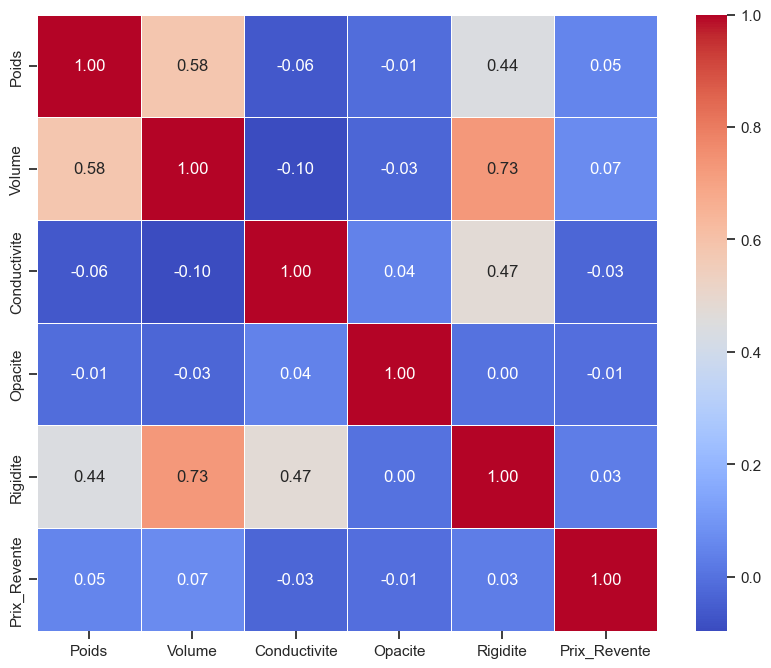

In [171]:
numeric_df = df.select_dtypes(include='number')
correlations = numeric_df.corr(method='pearson')
plt.figure(figsize=(10, 8))
sns.heatmap(correlations, annot=True, cmap='coolwarm', fmt=".2f", 
linewidths=.5)

### Etape 13 : Traiter les outliers

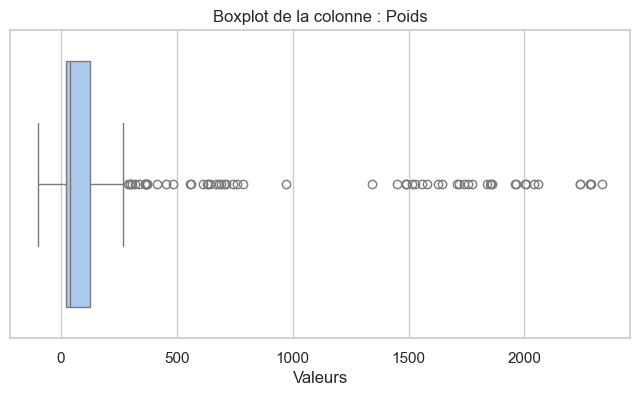

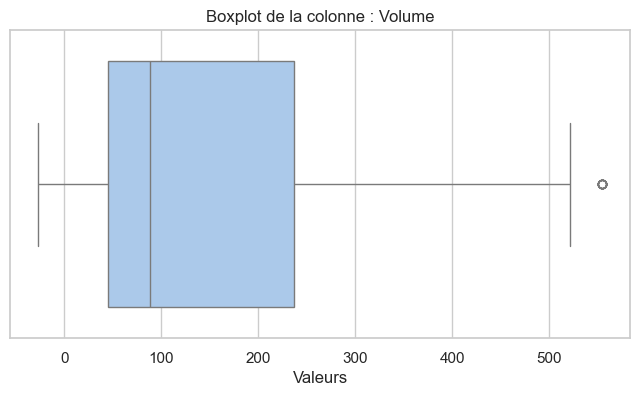

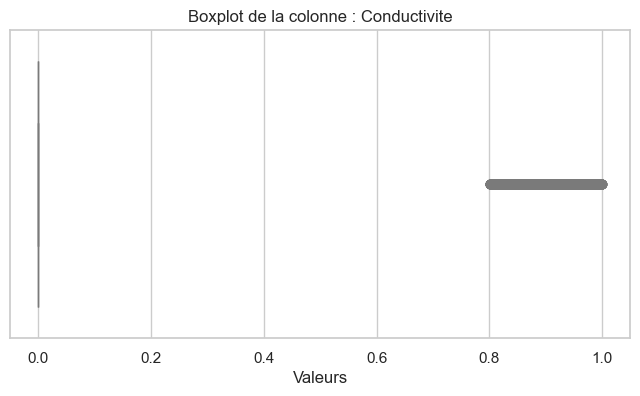

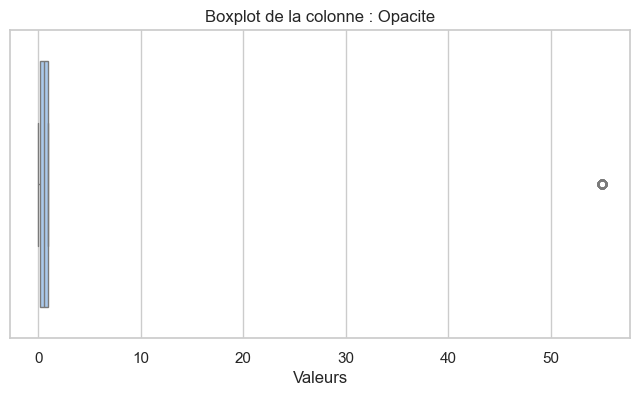

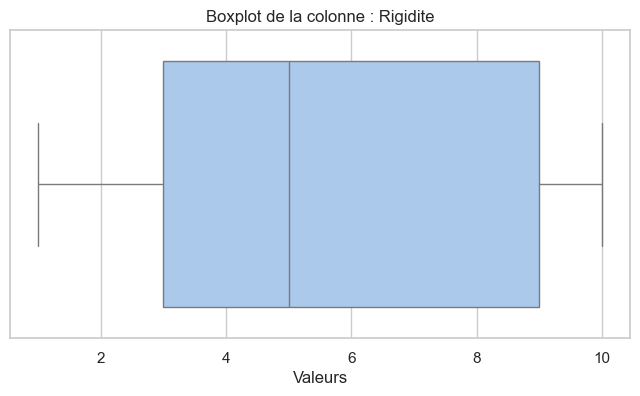

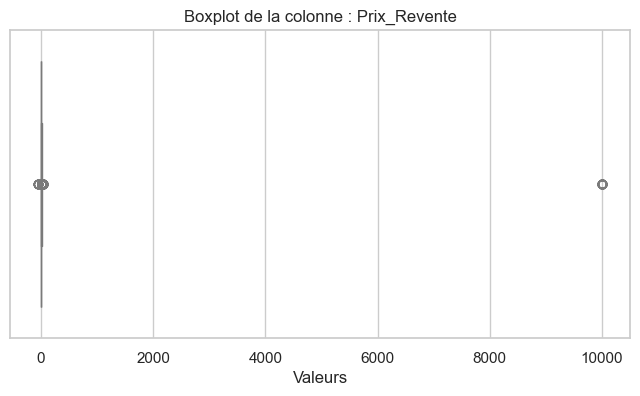

In [172]:
import seaborn as sns
import matplotlib.pyplot as plt
numeric_cols = df.select_dtypes(include=['float64', 'int64']).columns
sns.set(style='whitegrid')
for col in numeric_cols:
 plt.figure(figsize=(8, 4)) # Ajuster la taille de chaque figure
 sns.boxplot(data=df, x=col, orient='h', palette='pastel') # Boxplot horizontal
 plt.title(f"Boxplot de la colonne : {col}")
 plt.xlabel("Valeurs")
 plt.show()

In [189]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


### 12- Nous allons traiter les valeurs abbérantes que la colonne "" en remplaçant ces valeurs par la médiane

#### a-calculer les 4 quartiles (Q1,Q3,IRQ) et Sup, Inf

In [185]:
Q1 = df["Poids"].quantile(0.25)
Q3 = df["Poids"].quantile(0.75)
IQR = Q3 - Q1

inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR


#### b-remplacer les VA par la mediane de la colonne

In [186]:
outliers = df[(df['Poids'] < inf) | (df['Poids'] > sup)]
print(outliers)
for i in df['Poids']:
    if i >=sup or i<=inf:
        df['Poids']=df['Poids'].replace(i,np.median(df['Poids']))

         Poids     Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
327   0.406231  -1.925885           0.0  1.000000       1.0      0.160694   
402   0.419845   7.938003           0.0  1.000000       1.0      0.196156   
595   0.416404   7.209777           0.0  0.581208       4.0      0.343202   
619   0.364633   7.936824           0.0  1.000000       3.0      0.094352   
710   0.422580  37.335609           0.0  1.000000       2.0      0.204550   
820   0.423093  43.652804           0.0  1.000000       2.0      0.206178   
1323  0.406231  -1.925885           0.0  1.000000       1.0      0.160694   
1398  0.419845   7.938003           0.0  1.000000       1.0      0.196156   
1588  0.416404   7.209777           0.0  0.581208       4.0      0.343202   
1612  0.364633   7.936824           0.0  1.000000       3.0      0.094352   
1701  0.422580  37.335609           0.0  1.000000       2.0      0.204550   
1811  0.423093  43.652804           0.0  1.000000       2.0      0.206178   

#### c-vérifier la modification des VA

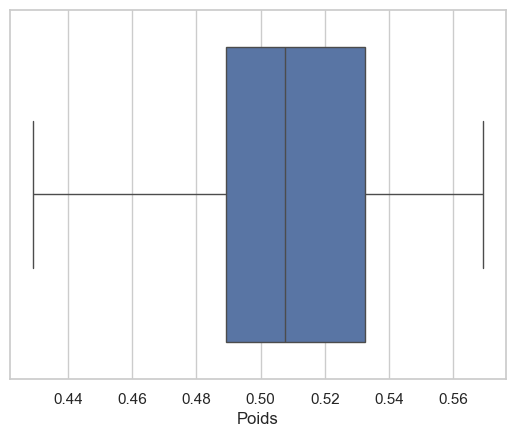

In [187]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Poids'] ,orient='h')

### 13- supprimer les VA de la colonne ''

In [82]:
Q1 = df['Volume'].quantile(0.25)
Q3 = df['Volume'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Volume'] >= inf) & (df['Volume'] <= sup)]


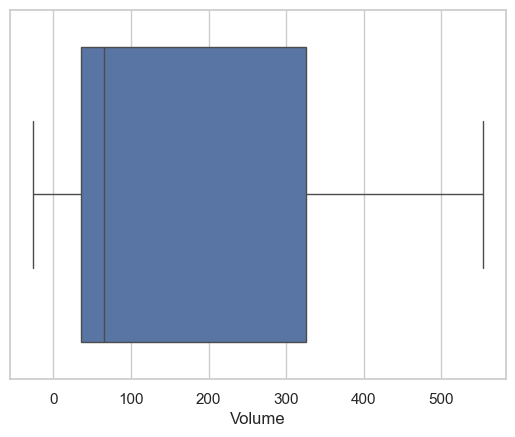

In [83]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Volume'] ,orient='h')

### *13- Traiter les VA de la colonne 

In [84]:
Q1 = df['Conductivite'].quantile(0.25)
Q3 = df['Conductivite'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Conductivite'] >= inf) & (df['Conductivite'] <= sup)]


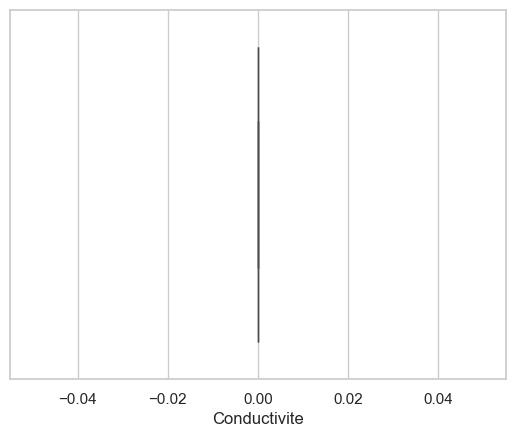

In [190]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Conductivite'] ,orient='h')

In [86]:
Q1 = df['Prix_Revente'].quantile(0.25)
Q3 = df['Prix_Revente'].quantile(0.75)
IQR = Q3 - Q1
inf = Q1 - 1.5 * IQR
sup = Q3 + 1.5 * IQR
df = df[(df['Prix_Revente'] >= inf) & (df['Prix_Revente'] <= sup)]


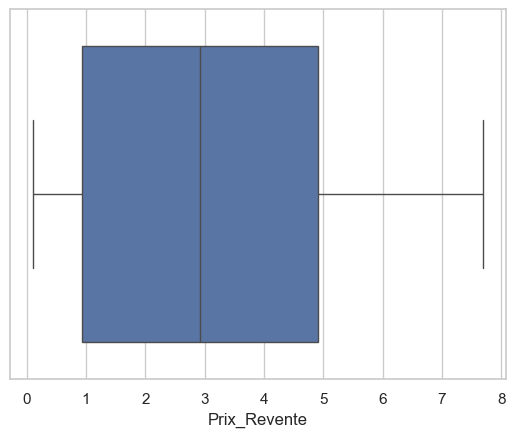

In [87]:
sns.set(style='whitegrid')
ax=sns.boxplot(data=df['Prix_Revente'] ,orient='h')

Text(0, 0.5, 'Volume')

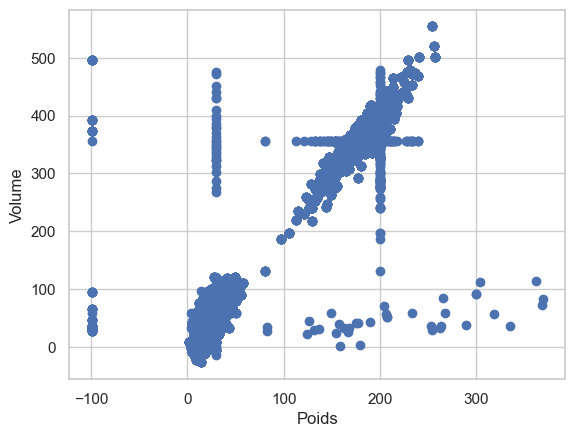

In [88]:
plt.scatter(x=df['Poids'],y=df['Volume'])
plt.xlabel('Poids')
plt.ylabel('Volume')


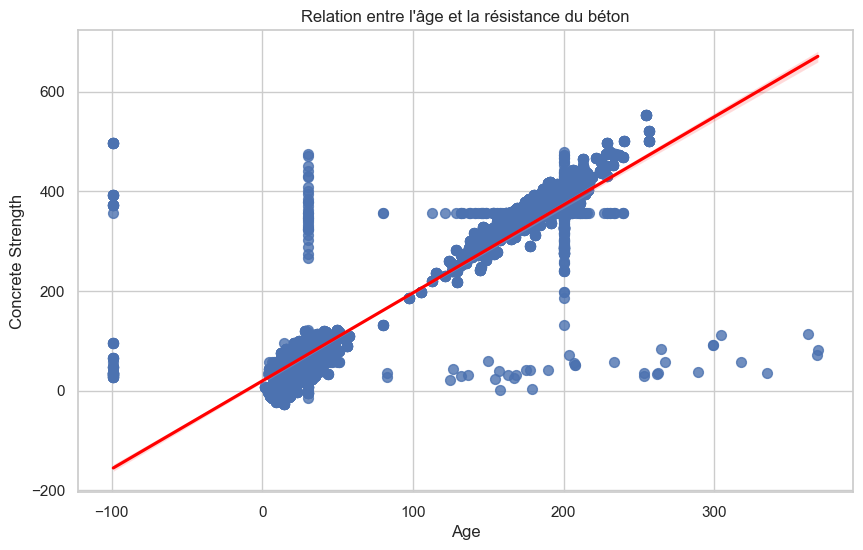

In [89]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Poids', y='Volume', data=df, scatter_kws={'s': 50}, line_kws={'color': 'red'})
plt.title('Relation entre l\'âge et la résistance du béton')
plt.xlabel('Age')
plt.ylabel('Concrete Strength')
plt.grid(True)
plt.show()

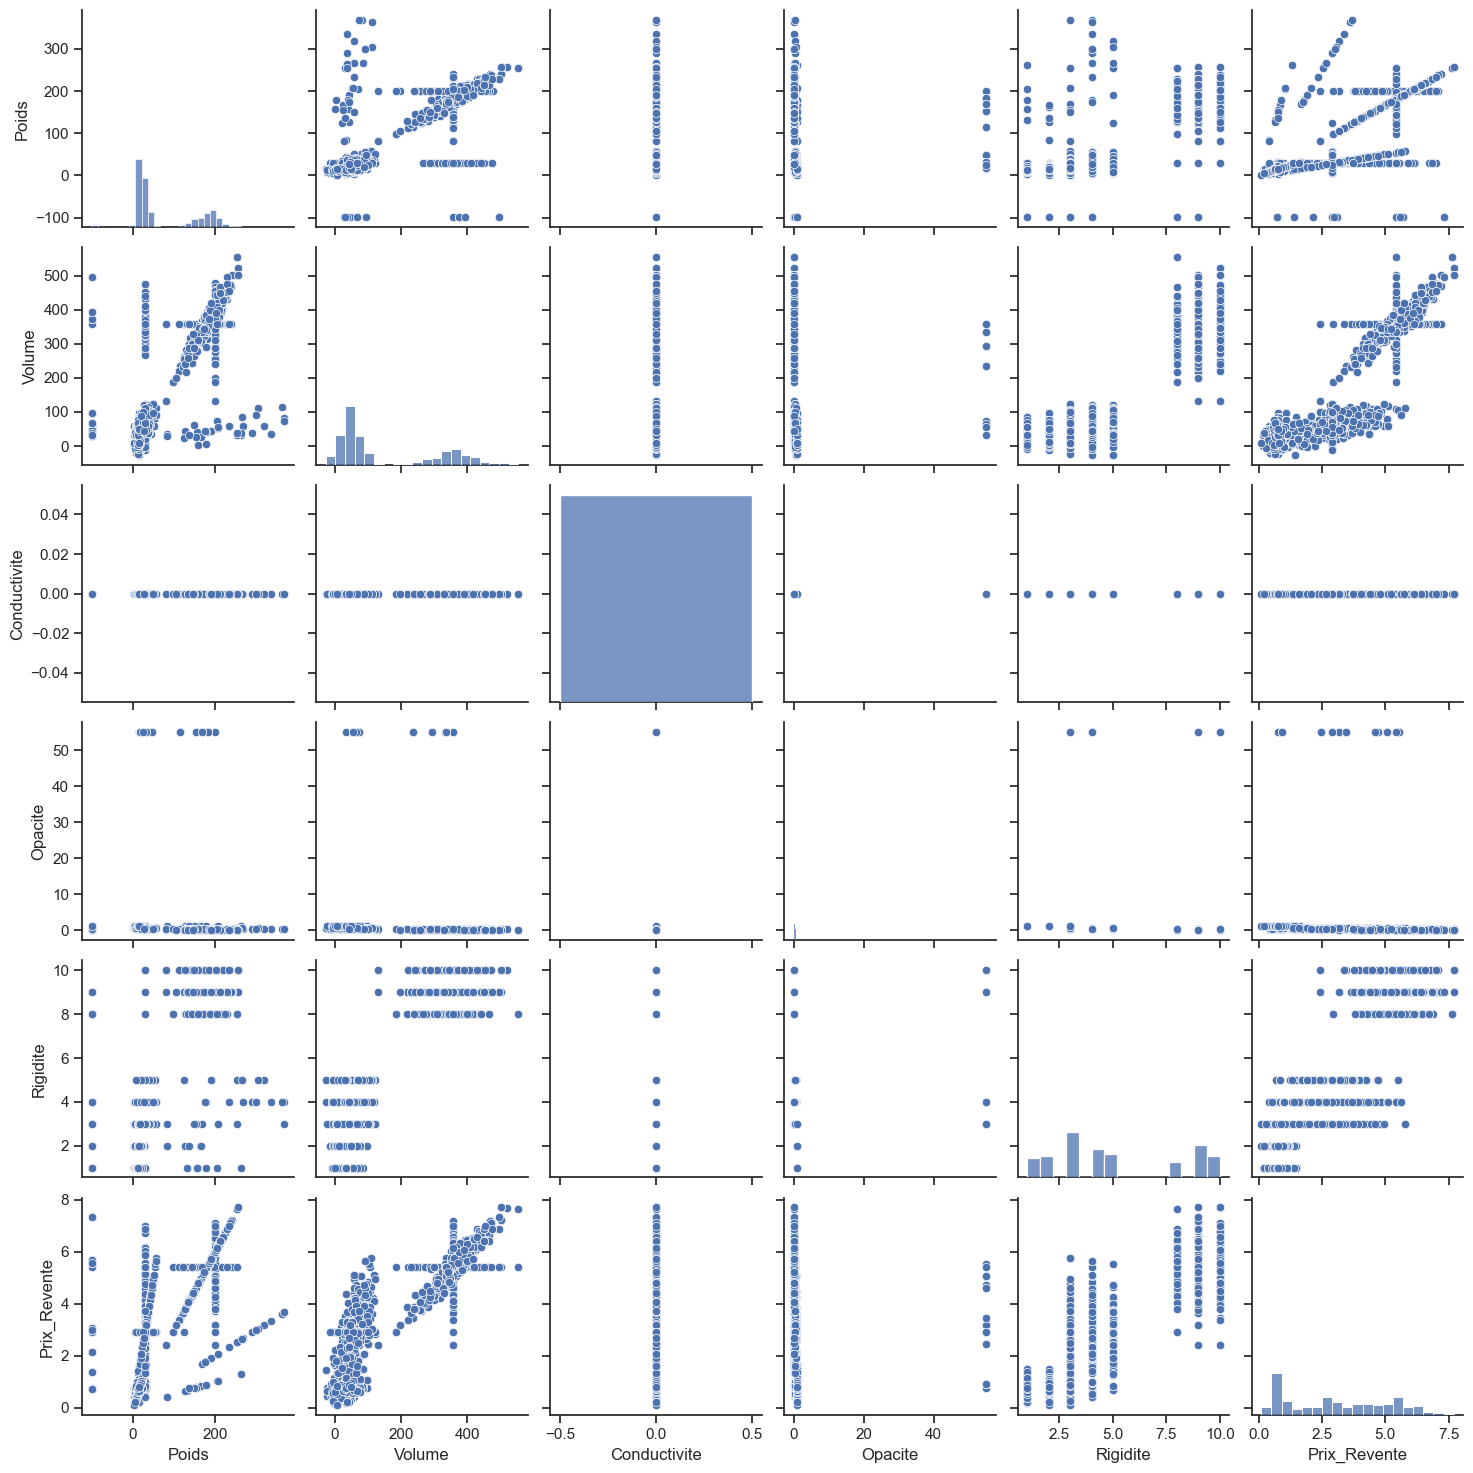

In [90]:
sns.set(style='ticks')
sns.pairplot(df)

### 14- affecter à Y (cible) la dernière colonne () et le reste du dataframe au entrées X

In [91]:
Y_class = df['Categorie']
X_class = df.drop(['Categorie', 'Rapport_Collecte'], axis=1)  # garde le DataFrame (pas .values)
print("Cible Y :")
print(Y_class)
print("\nEntrées X :")
print(X_class)

Cible Y :
0          Papier
1       Plastique
2           Verre
3          Papier
4          Papier
          ...    
9719        Verre
9720        Verre
9721       Papier
9722    Plastique
9723        Verre
Name: Categorie, Length: 7000, dtype: object

Entrées X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
0      16.708780   70.940977           0.0  1.000000       1.0      0.835439   
1      47.277476   64.702925           0.0  0.400606       3.0      4.727748   
2     200.203552  317.415183           0.0  0.105535       9.0      4.211790   
3      14.664058   21.474391           0.0  1.000000       1.0      0.442067   
4      14.664058   59.462176           0.0  1.000000       2.0      0.723004   
...          ...         ...           ...       ...       ...           ...   
9719  191.018619  418.800912           0.0  0.019307       9.0      5.730559   
9720  149.052713  287.519460           0.0  0.157940      10.0      4.471581   
9721   15.5726

In [92]:
X_regg = df.drop(["Prix_Revente", "Rapport_Collecte"], axis=1)
Y_regg = df["Prix_Revente"]
print("Cible Y :")
print(Y_regg)
print("\nEntrées X :")
print(X_regg)

Cible Y :
0       0.835439
1       4.727748
2       4.211790
3       0.442067
4       0.723004
          ...   
9719    5.730559
9720    4.471581
9721    0.778633
9722    2.670726
9723    4.400482
Name: Prix_Revente, Length: 7000, dtype: float64

Entrées X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
0      16.708780   70.940977           0.0  1.000000       1.0     Papier   
1      47.277476   64.702925           0.0  0.400606       3.0  Plastique   
2     200.203552  317.415183           0.0  0.105535       9.0      Verre   
3      14.664058   21.474391           0.0  1.000000       1.0     Papier   
4      14.664058   59.462176           0.0  1.000000       2.0     Papier   
...          ...         ...           ...       ...       ...        ...   
9719  191.018619  418.800912           0.0  0.019307       9.0      Verre   
9720  149.052713  287.519460           0.0  0.157940      10.0      Verre   
9721   15.572667   50.148243           0.0  1.00

In [93]:
print(type(X_regg))
print(X_regg.columns)

<class 'pandas.core.frame.DataFrame'>
Index(['Poids', 'Volume', 'Conductivite', 'Opacite', 'Rigidite', 'Categorie',
       'Source'],
      dtype='object')


### 15- afficher un echontillion de X et Y

In [94]:
print('Echantillon de X :')
print(X_class.iloc[np.random.choice(len(X_class), 5)])
print('\nEchantillon de Y :')
print(Y_class.iloc[np.random.choice(len(Y_class), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Prix_Revente  \
3033   16.084305   41.010944           0.0  1.000000       2.0      0.804215   
8691  230.689110  478.789744           0.0  0.046166       9.0      6.920673   
5827   23.973522   73.984027           0.0  0.227569       5.0      2.397352   
5948   27.426235   21.480788           0.0  0.547309       4.0      2.742623   
8573    9.979296    4.602641           0.0  1.000000       1.0      0.498965   

       Source  
3033  Usine_A  
8691  Usine_B  
5827  Usine_A  
5948  Usine_B  
8573  Usine_A  

Echantillon de Y :
3935     Verre
8244     Verre
7714    Papier
8874    Papier
7978     Verre
Name: Categorie, dtype: object


In [95]:
print('Echantillon de X :')
print(X_regg.iloc[np.random.choice(len(X_regg), 5)])
print('\nEchantillon de Y :')
print(Y_regg.iloc[np.random.choice(len(Y_regg), 5)])

Echantillon de X :
           Poids      Volume  Conductivite   Opacite  Rigidite  Categorie  \
8287  167.012975  340.314929           0.0  0.105535       9.0      Verre   
4296   25.016376   58.048818           0.0  0.269505       3.0  Plastique   
4229    8.297234   34.854473           0.0  1.000000       2.0     Papier   
8570   16.280807   32.163982           0.0  1.000000       3.0     Papier   
2508  179.204362  340.771231           0.0  0.015530       9.0      Verre   

                  Source  
8287          Centre_Tri  
4296  Collecte_Citoyenne  
4229          Centre_Tri  
8570          Centre_Tri  
2508          Centre_Tri  

Echantillon de Y :
1162    2.893349
2387    2.819520
7371    0.984794
4254    5.196164
5577    4.290058
Name: Prix_Revente, dtype: float64


### 17- transformer les colonnes catégoriques en numérique

In [96]:
# Encoder la cible Y
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
Y_class = le.fit_transform(Y_class.astype(str))  # astype(str) gère les NaN

In [97]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Trouver l'index de 'Source' dans X_class
source_idx = X_class.columns.get_loc('Source')

ct = ColumnTransformer(
    [('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), [source_idx])],
    remainder='passthrough'
)
X_class = ct.fit_transform(X_class)

In [98]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

ct = ColumnTransformer(
    transformers=[
        ('Source', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Source']),
        ('Categorie', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), ['Categorie'])
    ],
    remainder='passthrough'
)

X_regg = ct.fit_transform(X_regg)

### - Transformer X et Y en tableau numpy

In [99]:
X_class = np.array(X_class, dtype=float)
Y_class = np.array(Y_class)

print("Shape de X après encodage :", X_class.shape)
print("Shape de Y :", Y_class.shape)

Shape de X après encodage : (7000, 10)
Shape de Y : (7000,)


In [100]:
X_regg = np.array(X_regg, dtype=float)
Y_regg = np.array(Y_regg)

print("Shape de X après encodage :", X_regg.shape)
print("Shape de Y :", Y_regg.shape)

Shape de X après encodage : (7000, 12)
Shape de Y : (7000,)


### 18- Vérifier cette transformation

In [101]:
X_class[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.67087799e+01, 7.09409765e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 8.35438994e-01],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        4.72774763e+01, 6.47029253e+01, 0.00000000e+00, 4.00606185e-01,
        3.00000000e+00, 4.72774763e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        2.00203552e+02, 3.17415183e+02, 0.00000000e+00, 1.05535493e-01,
        9.00000000e+00, 4.21179011e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.46640579e+01, 2.14743907e+01, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 4.42067308e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.46640579e+01, 5.94621756e+01, 0.00000000e+00, 1.00000000e+00,
        2.00000000e+00, 7.23003759e-01],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
   

In [102]:
Y_class

array([0, 1, 2, ..., 0, 1, 2])

In [103]:
X_regg[0:10,:]

array([[0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.67087799e+01,
        7.09409765e+01, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 0.00000000e+00,
        0.00000000e+00, 1.00000000e+00, 0.00000000e+00, 4.72774763e+01,
        6.47029253e+01, 0.00000000e+00, 4.00606185e-01, 3.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        0.00000000e+00, 0.00000000e+00, 1.00000000e+00, 2.00203552e+02,
        3.17415183e+02, 0.00000000e+00, 1.05535493e-01, 9.00000000e+00],
       [1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 0.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.46640579e+01,
        2.14743907e+01, 0.00000000e+00, 1.00000000e+00, 1.00000000e+00],
       [0.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.00000000e+00,
        1.00000000e+00, 0.00000000e+00, 0.00000000e+00, 1.46

In [104]:
Y_regg

array([0.83543899, 4.72774763, 4.21179011, ..., 0.77863334, 2.67072629,
       4.40048174])

### 19- Subdiviser la dataset en deux parties train et test

In [105]:
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(
    X_class, Y_class, test_size=0.2, random_state=0
)

print('x_train:', x_train.shape)
print('x_test:', x_test.shape)
print('y_train:', y_train.shape)
print('y_test:', y_test.shape)

print('y_train mean:', y_train.mean())
print('y_test mean:', y_test.mean())

x_train: (5600, 10)
x_test: (1400, 10)
y_train: (5600,)
y_test: (1400,)
y_train mean: 1.0317857142857143
y_test mean: 1.0557142857142856


In [106]:
from sklearn.model_selection import train_test_split
x_train_reg , x_test_reg ,y_train_reg ,y_test_reg =train_test_split(X_regg,Y_regg,test_size =0.2 ,random_state=0)
print('x_train:',x_train_reg.shape)
print('x_test:',x_test_reg.shape)
print('y_train:',y_train_reg.shape)
print('y_test:',y_test_reg.shape)
print('y_train:',y_train_reg.mean())
print('y_test:',y_test_reg.mean())

x_train: (5600, 12)
x_test: (1400, 12)
y_train: (5600,)
y_test: (1400,)
y_train: 3.081039679052596
y_test: 3.1335359054199032


### 20- Mettre à l'échelle par standardisation les variables en entrée X_train et X_test

In [107]:
from sklearn.preprocessing import StandardScaler
sc = StandardScaler()
x_train = sc.fit_transform(x_train)
x_test = sc.transform(x_test)


In [108]:
print(x_train[:5])

[[ 1.86451572 -0.66496908 -0.57020185 -0.53826409 -2.1729409  -0.55866026
   0.         -0.00875933 -1.02249021 -0.84591993]
 [-0.5363323   1.50382932 -0.57020185 -0.53826409  1.57607242  1.88340294
   0.         -0.16134149  1.60861613  1.84535926]
 [-0.5363323  -0.66496908 -0.57020185  1.85782409 -0.7083848  -1.06874587
   0.         -0.00875933 -1.02249021 -1.09049711]
 [-0.5363323   1.50382932 -0.57020185 -0.53826409 -0.67722218 -0.5233143
   0.         -0.00875933 -1.3513785  -1.0284869 ]
 [-0.5363323  -0.66496908  1.75376492 -0.53826409 -0.60924485 -0.48744291
   0.         -0.09509989 -0.69360192 -0.25003017]]


In [109]:
from sklearn.preprocessing import StandardScaler
sc1 = StandardScaler()
x_train_reg = sc1.fit_transform(x_train_reg)
x_test_reg = sc1.transform(x_test_reg)

In [110]:
print(x_train_reg[:5])

[[ 1.86451572 -0.66496908 -0.57020185 -0.53826409  1.51271767 -0.75
  -0.7111829  -2.1729409  -0.55866026  0.         -0.00875933 -1.02249021]
 [-0.5363323   1.50382932 -0.57020185 -0.53826409 -0.66106189 -0.75
   1.40610804  1.57607242  1.88340294  0.         -0.16134149  1.60861613]
 [-0.5363323  -0.66496908 -0.57020185  1.85782409  1.51271767 -0.75
  -0.7111829  -0.7083848  -1.06874587  0.         -0.00875933 -1.02249021]
 [-0.5363323   1.50382932 -0.57020185 -0.53826409  1.51271767 -0.75
  -0.7111829  -0.67722218 -0.5233143   0.         -0.00875933 -1.3513785 ]
 [-0.5363323  -0.66496908  1.75376492 -0.53826409 -0.66106189  1.33333333
  -0.7111829  -0.60924485 -0.48744291  0.         -0.09509989 -0.69360192]]


# Modélisation KNN et évaluation

Il faut imputer les valeurs manquantes avant le fit. 

In [111]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report
import numpy as np

# --- Imputation des NaN (remplacement par la moyenne de chaque colonne) ---
imputer = SimpleImputer(strategy='mean')
x_train = imputer.fit_transform(x_train)
x_test  = imputer.transform(x_test)       # transform seulement, pas fit !

# --- Entraînement du modèle KNN ---
knn = KNeighborsClassifier(n_neighbors=3)
knn.fit(x_train, y_train)

# --- Prédictions ---
y_pred_knn = knn.predict(x_test)

# --- Conversion en entiers ---
y_test_eval = np.array(y_test).astype(int)
y_pred_knn  = np.array(y_pred_knn).astype(int)

# --- Évaluation ---
print('\nConfusion Matrix:\n', confusion_matrix(y_test_eval, y_pred_knn))
print(f'\nAccuracy  : {accuracy_score(y_test_eval, y_pred_knn):.4f}')
print(f'Recall    : {recall_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print(f'Precision : {precision_score(y_test_eval, y_pred_knn, average="macro"):.4f}')
print('\nClassification Report:\n', classification_report(y_test_eval, y_pred_knn))

# --- Aperçu des 10 premières prédictions ---
print("\nAperçu des 10 premières prédictions:")
for i in range(10):
    print(f"  [{i}] Vérité: {y_test_eval[i]}  →  Prédiction: {y_pred_knn[i]}")

KeyboardInterrupt: 

# Mdélisation Grid Search et évaluation

problème multiclasse, donc il faut average='macro'

In [ ]:
from sklearn.model_selection import GridSearchCV

parameters = {'n_neighbors': [1, 3, 5, 7, 9, 11, 13]}
model = KNeighborsClassifier()

clf = GridSearchCV(model, parameters, scoring='recall_macro', cv=5)
grille = clf.fit(x_train, y_train)

print("Meilleur paramètre :", grille.best_params_)
print("Meilleur score     :", grille.best_score_)

y_pred_knn_o = grille.predict(x_test)

knn_op_acc  = accuracy_score(y_test, y_pred_knn_o)
knn_op_rec  = recall_score(y_test, y_pred_knn_o, average='macro')
knn_op_prec = precision_score(y_test, y_pred_knn_o, average='macro')

print('\nConfusion Matrix KNN optimisé:\n', confusion_matrix(y_test, y_pred_knn_o))
print(f'Accuracy  : {knn_op_acc:.4f}')
print(f'Recall    : {knn_op_rec:.4f}')
print(f'Precision : {knn_op_prec:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_knn_o))

Meilleur paramètre : {'n_neighbors': 7}
Meilleur score     : 0.9631061593187729

Confusion Matrix KNN optimisé:
 [[370   5   0]
 [ 22 455  17]
 [  0   1 383]]
Accuracy  : 0.9641
Recall    : 0.9684
Precision : 0.9628

Classification Report:
               precision    recall  f1-score   support

           0       0.94      0.99      0.96       375
           1       0.99      0.92      0.95       494
           2       0.96      1.00      0.98       384

    accuracy                           0.96      1253
   macro avg       0.96      0.97      0.96      1253
weighted avg       0.97      0.96      0.96      1253



# Decision Tree

In [ ]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Decision Tree ---
dt = DecisionTreeClassifier(max_depth=5, random_state=0)
dt.fit(x_train, y_train)

# --- Prédictions ---
y_pred_dt = dt.predict(x_test)

# --- Évaluation ---
accur_dt = accuracy_score(y_test, y_pred_dt)
rec_dt   = recall_score(y_test, y_pred_dt, average='macro')
pres_dt  = precision_score(y_test, y_pred_dt, average='macro')

print('Confusion Matrix DT:\n', confusion_matrix(y_test, y_pred_dt))
print(f'Accuracy  : {accur_dt:.4f}')
print(f'Recall    : {rec_dt:.4f}')
print(f'Precision : {pres_dt:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_dt))

Confusion Matrix DT:
 [[373   2   0]
 [ 21 457  16]
 [  0   2 382]]
Accuracy  : 0.9673
Recall    : 0.9715
Precision : 0.9659

Classification Report:
               precision    recall  f1-score   support

           0       0.95      0.99      0.97       375
           1       0.99      0.93      0.96       494
           2       0.96      0.99      0.98       384

    accuracy                           0.97      1253
   macro avg       0.97      0.97      0.97      1253
weighted avg       0.97      0.97      0.97      1253



## Importance des features

# Random Forest

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, classification_report

# --- Entraînement Random Forest ---
rf = RandomForestClassifier(n_estimators=500, random_state=0)
rf.fit(x_train, y_train)

# --- Prédictions ---
y_pred_rf = rf.predict(x_test)

# --- Évaluation ---
rf_acc  = accuracy_score(y_test, y_pred_rf)
rf_rec  = recall_score(y_test, y_pred_rf, average='macro')
rf_prec = precision_score(y_test, y_pred_rf, average='macro')

print('Confusion Matrix RF:\n', confusion_matrix(y_test, y_pred_rf))
print(f'Accuracy  : {rf_acc:.4f}')
print(f'Recall    : {rf_rec:.4f}')
print(f'Precision : {rf_prec:.4f}')
print('\nClassification Report:\n', classification_report(y_test, y_pred_rf))

Confusion Matrix RF:
 [[374   1   0]
 [ 17 461  16]
 [  0   9 375]]
Accuracy  : 0.9657
Recall    : 0.9690
Precision : 0.9648

Classification Report:
               precision    recall  f1-score   support

           0       0.96      1.00      0.98       375
           1       0.98      0.93      0.96       494
           2       0.96      0.98      0.97       384

    accuracy                           0.97      1253
   macro avg       0.96      0.97      0.97      1253
weighted avg       0.97      0.97      0.97      1253



In [ ]:
!pip install shap

Defaulting to user installation because normal site-packages is not writeable


les 3 graphiques obligatoires
Graphique Feature Importance (importance des variables avec Random Forest)
Graphique SHAP Summary Plot (le plus important)
Graphique SHAP Bar Plot (les features les plus importantes)

# SVM linéaire

In [ ]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, precision_score, recall_score, confusion_matrix, classification_report

# === Ton code original (corrigé seulement le strict minimum) ===
linear_SVM = SVC(kernel='linear')
linear_SVM.fit(x_train, y_train)
y_predictSVM_l = linear_SVM.predict(x_test)

svm_acc  = accuracy_score(y_test, y_predictSVM_l)
svm_prec = precision_score(y_test, y_predictSVM_l, average='macro')
svm_rec  = recall_score(y_test, y_predictSVM_l, average='macro')

print(confusion_matrix(y_test, y_predictSVM_l))
print('Accuracy linear SVM {0:.3f}'.format(svm_acc))
print('Precision linear SVM {0:.3f}'.format(svm_prec))
print('Recall linear SVM {0:.3f}'.format(svm_rec))
print(classification_report(y_test, y_predictSVM_l))

[[369   6   0]
 [ 41 437  16]
 [  0   1 383]]
Accuracy linear SVM 0.949
Precision linear SVM 0.948
Recall linear SVM 0.955
              precision    recall  f1-score   support

           0       0.90      0.98      0.94       375
           1       0.98      0.88      0.93       494
           2       0.96      1.00      0.98       384

    accuracy                           0.95      1253
   macro avg       0.95      0.96      0.95      1253
weighted avg       0.95      0.95      0.95      1253



# Logistic Regression

In [ ]:
from sklearn.linear_model import LogisticRegression
LR = LogisticRegression()
LR.fit(x_train,y_train)

LogisticRegression()

In [ ]:
from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

y_predictLR = LR.predict(x_test)

LR_acc  = accuracy_score(y_test, y_predictLR)
LR_prec = metrics.precision_score(y_test, y_predictLR, average='macro')   # ← corrigé multi-classes
LR_rec  = metrics.recall_score(y_test, y_predictLR, average='macro')      # ← corrigé multi-classes

print(confusion_matrix(y_test, y_predictLR))
print('Accuracy Logistic Regression {0:.3f}'.format(LR_acc))
print('Precision Logistic Regression {0:.3f}'.format(LR_prec))
print('Recall Logistic Regression {0:.3f}'.format(LR_rec))

[[365  10   0]
 [ 40 438  16]
 [  0   5 379]]
Accuracy Logistic Regression 0.943
Precision Logistic Regression 0.943
Recall Logistic Regression 0.949


# Sommary

In [ ]:
print("| Algorithm         | Accuracy   | Recall     | Precision  |")
print("| ----------------- | ---------- | ---------- | ---------- |")
print("| Optimized kNN     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(knn_op_acc, knn_op_rec, knn_op_prec))
print("| Decision Tree     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(accur_dt, rec_dt, pres_dt))
print("| Random Forest     | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(rf_acc, rf_rec, rf_prec))
print("| Linear SVM        | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(svm_acc, svm_rec, svm_prec))
print("| Logistic Reg      | {0:.3f}    | {1:.3f}    | {2:.3f}    |".format(LR_acc, LR_rec, LR_prec))

| Algorithm         | Accuracy   | Recall     | Precision  |
| ----------------- | ---------- | ---------- | ---------- |
| Optimized kNN     | 0.964    | 0.968    | 0.963    |
| Decision Tree     | 0.967    | 0.972    | 0.966    |
| Random Forest     | 0.966    | 0.969    | 0.965    |
| Linear SVM        | 0.949    | 0.955    | 0.948    |
| Logistic Reg      | 0.943    | 0.949    | 0.943    |


# Ajouter F1 score 


F1-score (macro) pour chaque modèle

In [ ]:
from sklearn.metrics import f1_score

knn_op_f1 = f1_score(y_test, y_pred_knn_o, average='macro')
dt_f1     = f1_score(y_test, y_pred_dt, average='macro')
rf_f1     = f1_score(y_test, y_pred_rf, average='macro')
svm_f1    = f1_score(y_test, y_predictSVM_l, average='macro')
LR_f1     = f1_score(y_test,  y_predictLR, average='macro')  # si Logistic Regression existefrom sklearn.metrics import f1_score

knn_op_f1 = f1_score(y_test, y_pred_knn_o, average='macro')
dt_f1     = f1_score(y_test, y_pred_dt, average='macro')
rf_f1     = f1_score(y_test, y_pred_rf, average='macro')
svm_f1    = f1_score(y_test, y_predictSVM_l, average='macro')
LR_f1     = f1_score(y_test,  y_predictLR, average='macro')  # si Logistic Regression existe

# Regression

In [ ]:
# =========================================================
# 1) Importation des bibliothèques
# =========================================================
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# =========================================================
# 2) Charger le dataset
# =========================================================
df = pd.read_csv("dataset_ProjetML_2026.csv")

print("Dimensions du dataset :", df.shape)
print(df.head())

# =========================================================
# 3) Supprimer les lignes où la cible est manquante
# =========================================================
df = df.dropna(subset=["Prix_Revente"]).copy()

# =========================================================
# 4) Définir X et y
# =========================================================
X = df.drop("Prix_Revente", axis=1)
y = df["Prix_Revente"]

# =========================================================
# 5) Définir les colonnes
# =========================================================
numeric_features = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]
categorical_features = ["Categorie", "Source"]
text_feature = "Rapport_Collecte"

# =========================================================
# 6) Prétraitement
# =========================================================

# Pipeline pour les colonnes numériques
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# Pipeline pour les colonnes catégorielles
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Pipeline pour la colonne texte
text_transformer = Pipeline(steps=[
    ("tfidf", TfidfVectorizer(max_features=300))
])

# Combinaison de tous les prétraitements
preprocessor = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
    ("txt", text_transformer, text_feature)
])

# =========================================================
# 7) Division Train / Test
# =========================================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# =========================================================
# 8) Définir plusieurs modèles de régression
# =========================================================
models = {
    "LinearRegression": LinearRegression(),
    "Ridge": Ridge(alpha=1.0),
    "RandomForest": RandomForestRegressor(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "GradientBoosting": GradientBoostingRegressor(
        random_state=42
    )
}

# =========================================================
# 9) Entraîner et évaluer chaque modèle
# =========================================================
results = []

for name, model in models.items():
    pipeline = Pipeline(steps=[
        ("preprocessor", preprocessor),
        ("model", model)
    ])
    
    pipeline.fit(X_train, y_train)
    y_pred = pipeline.predict(X_test)
    
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_test, y_pred)
    
    results.append({
        "Modele": name,
        "MAE": mae,
        "MSE": mse,
        "RMSE": rmse,
        "R2": r2
    })
    
    print(f"\n===== {name} =====")
    print("MAE  =", mae)
    print("MSE  =", mse)
    print("RMSE =", rmse)
    print("R2   =", r2)

# =========================================================
# 10) Tableau comparatif des résultats
# =========================================================
results_df = pd.DataFrame(results).sort_values(by="R2", ascending=False)

print("\nTableau des performances :")
print(results_df)

# =========================================================
# 11) Choisir le meilleur modèle
# =========================================================
best_model_name = results_df.iloc[0]["Modele"]
print("\nMeilleur modèle :", best_model_name)

best_model = models[best_model_name]

best_pipeline = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("model", best_model)
])

best_pipeline.fit(X_train, y_train)

# =========================================================
# 12) Prédictions sur l'ensemble de test
# =========================================================
y_pred_best = best_pipeline.predict(X_test)

# =========================================================
# 13) Générer une nouvelle colonne avec le prix prédit
# =========================================================
X_test_result = X_test.copy()
X_test_result["Prix_Revente_Reel"] = y_test.values
X_test_result["Prix_Revente_Predit"] = y_pred_best

print("\nAperçu des prédictions :")
print(X_test_result.head())

# =========================================================
# 14) Sauvegarder le résultat dans un fichier CSV
# =========================================================
X_test_result.to_csv("resultats_regression_prix_revente.csv", index=False)

print("\nFichier sauvegardé : resultats_regression_prix_revente.csv")

Dimensions du dataset : (10500, 9)
       Poids      Volume  Conductivite  Opacite  Rigidite  Prix_Revente  \
0  16.708780   70.940977           0.0      1.0       1.0      0.835439   
1  47.277476   64.702925           0.0      NaN       3.0      4.727748   
2        NaN  317.415183           0.0      NaN       9.0      4.211790   
3        NaN   21.474391           0.0      NaN       1.0      0.442067   
4        NaN   59.462176           0.0      1.0       NaN      0.723004   

   Categorie      Source                                   Rapport_Collecte  
0     Papier         NaN  Lot de papier récupéré dans un site non rensei...  
1  Plastique     Usine_A  Lot plastique à l'Usine A. Volume 64.7 L, poid...  
2      Verre     Usine_B  Bris de verre ou contenants en provenance de l...  
3     Papier  Centre_Tri  Feuilles et cartons collectés au Centre de Tri...  
4     Papier     Usine_B  Déchet de type papier identifié à l'Usine B. V...  

===== LinearRegression =====
MAE  = 165.21271

# Régression linéaire

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import (
    r2_score,
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error,
    median_absolute_error
)
import numpy as np
import pandas as pd

linear_model = LinearRegression()
linear_model.fit(x_train_reg, y_train_reg)

y_pred_lr = linear_model.predict(x_test_reg)

r2_lr = r2_score(y_test_reg, y_pred_lr)
mae_lr = mean_absolute_error(y_test_reg, y_pred_lr)
mse_lr = mean_squared_error(y_test_reg, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)
mape_lr = mean_absolute_percentage_error(y_test_reg, y_pred_lr)
medae_lr = median_absolute_error(y_test_reg, y_pred_lr)

print("===== Régression Linéaire =====")
print("R2    :", r2_lr)
print("MAE   :", mae_lr)
print("MSE   :", mse_lr)
print("RMSE  :", rmse_lr)
print("MAPE  :", mape_lr)
print("MEDAE :", medae_lr)

results_lr = pd.DataFrame(x_test_reg)
results_lr["prix_reel"] = y_test_reg
results_lr["prix_predit"] = y_pred_lr

print(results_lr.head())

===== Régression Linéaire =====
R2    : 0.008119044478171245
MAE   : 129.10540604480843
MSE   : 690894.7587506416
RMSE  : 831.2007932808062
MAPE  : 25.873408299695406
MEDAE : 46.66904845609519
          0         1         2         3         4         5         6  \
0 -0.541437 -0.664191 -0.566581  1.860255  1.880614 -0.533294 -0.674015   
1 -0.541437 -0.664191  1.764972 -0.537561  1.880614 -0.533294 -0.674015   
2 -0.541437  1.505591 -0.566581 -0.537561 -0.531741 -0.533294  1.483646   
3 -0.541437 -0.664191  1.764972 -0.537561 -0.531741 -0.533294 -0.674015   
4  1.846938 -0.664191 -0.566581 -0.537561 -0.531741 -0.533294 -0.674015   

          7         8         9        10        11        12    prix_reel  \
0 -0.570831 -0.451166 -0.961265  1.906914 -0.026711  0.697868     6.672856   
1 -0.570831 -0.335028 -0.311799  1.766505 -0.026711  1.029330    10.973280   
2 -0.570831 -0.522848 -0.614556 -0.578895 -0.140902 -0.959442     1.339517   
3  1.751831  1.407831  2.622586 -0.578895 -0

# Régression Ridge/Lasso (avec régularisation)


In [ ]:
from sklearn.linear_model import Ridge
# création du modèle
ridge_model = Ridge(alpha=1.0)
# entraînement
ridge_model.fit(x_train, y_train)
# prédictions
y_pred_ridge = ridge_model.predict(x_test)

In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
import numpy as np
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)
mse_ridge = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)
mape_ridge = mean_absolute_percentage_error(y_test, y_pred_ridge)
medae_ridge = median_absolute_error(y_test, y_pred_ridge)
print("Ridge Regression")
print("R2 :", r2_ridge)
print("MAE :", mae_ridge)
print("MSE :", mse_ridge)
print("RMSE :", rmse_ridge)
print("MAPE :", mape_ridge)
print("MEDAE :",medae_ridge)

# Régression Lasso

In [ ]:
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
# création du modèle
lasso_model = Lasso(alpha=0.1)
# entraînement
lasso_model.fit(x_train, y_train)
# prédictions
y_pred_lasso = lasso_model.predict(x_test)

In [ ]:
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)
mse_lasso = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)
mape_lasso = mean_absolute_percentage_error(y_test, y_pred_lasso)
medae_lasso = median_absolute_error(y_test, y_pred_lasso)
print("Lasso Regression")
print("R2 :", r2_lasso)
print("MAE :", mae_lasso)
print("MSE :", mse_lasso)
print("RMSE :", rmse_lasso)
print("MAPE :",mape_lasso)
print("MEDAE :",medae_lasso)

# ElasticNet

In [ ]:
from sklearn.linear_model import ElasticNet
# création du modèle
elastic_model = ElasticNet(alpha=0.1, l1_ratio=0.5)
# entraînement
elastic_model.fit(x_train, y_train)
# prédictions
y_pred_elastic = elastic_model.predict(x_test)


In [ ]:
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
import numpy as np
r2_elastic = r2_score(y_test, y_pred_elastic)
mae_elastic = mean_absolute_error(y_test, y_pred_elastic)
mse_elastic = mean_squared_error(y_test, y_pred_elastic)
rmse_elastic = np.sqrt(mse_elastic)
print("ElasticNet Regression")
print("R2 :", r2_elastic)
print("MAE :", mae_elastic)
print("MSE :", mse_elastic)
print("RMSE :", rmse_elastic)

# Coefficients

In [ ]:
import pandas as pd
coefficients = elastic_model.coef_
feature_names = df.columns[:-1]
coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": coefficients
})
print(coef_df)

# Régression polynomiale

In [ ]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
poly_model = Pipeline([
    ("poly", PolynomialFeatures(degree=2)),
    ("linear", LinearRegression())
])
poly_model.fit(x_train, y_train)
y_pred_poly = poly_model.predict(x_test)
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
import numpy as np
r2_poly = r2_score(y_test, y_pred_poly)
mae_poly = mean_absolute_error(y_test, y_pred_poly)
mse_poly = mean_squared_error(y_test, y_pred_poly)
rmse_poly = np.sqrt(mse_poly)
mape_poly = mean_absolute_percentage_error(y_test, y_pred_poly)
medae_poly = median_absolute_error(y_test, y_pred_poly)
print("Polynomial Regression")
print("R2 :", r2_poly)
print("MAE :", mae_poly)
print("MSE :", mse_poly)
print("RMSE :", rmse_poly)
print("MAPE :",mape_poly)
print("MEDAE :",medae_poly)

#  DecisionTreeRegressor

In [ ]:
from sklearn.tree import DecisionTreeRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
tree_model = DecisionTreeRegressor(max_depth=5)
tree_model.fit(x_train, y_train)
y_pred_tree = tree_model.predict(x_test)
r2_tree = r2_score(y_test, y_pred_tree)
mae_tree = mean_absolute_error(y_test, y_pred_tree)
mse_tree = mean_squared_error(y_test, y_pred_tree)
rmse_tree = np.sqrt(mse_tree)
mape_tree = mean_absolute_percentage_error(y_test, y_pred_tree)
medae_tree = median_absolute_error(y_test, y_pred_tree)
print("Decision Tree Regressor")
print("R2 :", r2_tree)
print("MAE :", mae_tree)
print("MSE :", mse_tree)
print("RMSE :", rmse_tree)
print("MAPE :",mape_tree)
print("MEDAE :",medae_tree)

#  RandomForestRegressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
rf_model = RandomForestRegressor(
    n_estimators=200,
    max_depth=10,
    random_state=42
)
rf_model.fit(x_train, y_train)
y_pred_rf = rf_model.predict(x_test)
r2_rf = r2_score(y_test, y_pred_rf)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)
mape_rf = mean_absolute_percentage_error(y_test, y_pred_rf)
medae_rf = median_absolute_error(y_test, y_pred_rf)
print("Random Forest")
print("R2 :", r2_rf)
print("MAE :", mae_rf)
print("MSE :", mse_rf)
print("RMSE :", rmse_rf)
print("MAPE :",mape_rf)
print("MEDAE :",medae_rf)

# GradientBoostingRegressor


In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
gbr_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3
)
gbr_model.fit(x_train, y_train)
y_pred_gbr = gbr_model.predict(x_test)
r2_gbr = r2_score(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)
mse_gbr = mean_squared_error(y_test, y_pred_gbr)
rmse_gbr = np.sqrt(mse_gbr)
mape_gbr = mean_absolute_percentage_error(y_test, y_pred_gbr)
medae_gbr = median_absolute_error(y_test, y_pred_gbr)
print("Gradient Boosting")
print("R2 :", r2_gbr)
print("MAE :", mae_gbr)
print("MSE :", mse_gbr)
print("RMSE :", rmse_gbr)
print("MAPE :",mape_gbr)
print("MEDAE :",medae_gbr)

# GridSearch GradientBoostingRegressor

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
gbr = GradientBoostingRegressor()
param_grid = {
    'n_estimators': [100,200],
    'learning_rate': [0.01,0.1],
    'max_depth': [3,5]
}
grid_gbr = GridSearchCV(gbr, param_grid, cv=5)
grid_gbr.fit(x_train, y_train)
best_model_gbr = grid_gbr.best_estimator_
importances = best_model_gbr.feature_importances_
feature_names = df.columns
feature_names=feature_names[:-1]
# Créer un DataFrame pour afficher les importances
import matplotlib.pyplot as plt
feature_importances = pd.Series(importances, index=feature_names).sort_values(ascending=False)
feature_importances.plot(kind='bar', title='Feature Importances')

In [ ]:
param_grid = {
    'n_estimators': [100, 200],
    'learning_rate': [0.01, 0.05, 0.1],
    'max_depth': [3,4,5]
}
grid = GridSearchCV(
    gbr,
    param_grid,
    cv=5,
    scoring="r2"
)
grid.fit(x_train, y_train)
best_model_gbr = grid.best_estimator_
y_pred_best = best_model_gbr.predict(x_test)
r2_best = r2_score(y_test, y_pred_best)
mae_best = mean_absolute_error(y_test, y_pred_best)
mse_best = mean_squared_error(y_test, y_pred_best)
rmse_best = np.sqrt(mse_best)
mape_best = mean_absolute_percentage_error(y_test, y_pred_best)
medae_best = median_absolute_error(y_test, y_pred_best)
print("Best GradientBoosting")
print("Best Params :", grid.best_params_)
print("R2 :", r2_best)
print("RMSE :", rmse_best)
print("MAPE :",mape_best)
print("MEDAE :",medae_best)

# XGBoost

In [ ]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6
)
xgb_model.fit(x_train, y_train)
y_pred_xgb = xgb_model.predict(x_test)
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)
mse_xgb = mean_squared_error(y_test, y_pred_xgb)
rmse_xgb = np.sqrt(mse_xgb)
mape_xgb = mean_absolute_percentage_error(y_test, y_pred_xgb)
medae_xgb = median_absolute_error(y_test, y_pred_xgb)
print("XGBoost")
print("R2 :", r2_xgb)
print("RMSE :", rmse_xgb)
print("MAPE :",mape_xgb)
print("MEDAE :",medae_xgb)

# LightGBM

In [ ]:
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
lgb_model = LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05
)
lgb_model.fit(x_train, y_train)
y_pred_lgb = lgb_model.predict(x_test)
r2_lgb = r2_score(y_test, y_pred_lgb)
mae_lgb = mean_absolute_error(y_test, y_pred_lgb)
mse_lgb = mean_squared_error(y_test, y_pred_lgb)
rmse_lgb = np.sqrt(mse_lgb)
mape_lgb = mean_absolute_percentage_error(y_test, y_pred_lgb)
medae_lgb = median_absolute_error(y_test, y_pred_lgb)
print("LightGBM")
print("R2 :", r2_lgb)
print("RMSE :", rmse_lgb)
print("MAPE :",mape_lgb)
print("MEDAE :",medae_lgb)

# CatBoost

In [ ]:
from catboost import CatBoostRegressor
catboost_model = CatBoostRegressor(
    iterations=500,
    learning_rate=0.05,
    depth=6,
    verbose=0
)
catboost_model.fit(x_train, y_train)

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
importances = catboost_model.feature_importances_
feature_names = df.columns[:-1]
feat_imp = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values(by="Importance", ascending=False)
print(feat_imp)
plt.figure(figsize=(10,6))
plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Feature Importance - CatBoost")
plt.gca().invert_yaxis()
plt.show()

In [ ]:
from catboost import CatBoostRegressor
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
# Initialiser le modèle CatBoost
cat_model = CatBoostRegressor(
    iterations=1000,      # nombre d'arbres
    learning_rate=0.1,    # taux d'apprentissage
    depth=6,              # profondeur des arbres
    verbose=0             # pour ne pas afficher l'entraînement
)
# Entraînement
cat_model.fit(x_train, y_train)
# Prédictions
y_pred_cat = cat_model.predict(x_test)
# Calcul des métriques
r2_cat = r2_score(y_test, y_pred_cat)
mae_cat = mean_absolute_error(y_test, y_pred_cat)
mse_cat = mean_squared_error(y_test, y_pred_cat)
rmse_cat = np.sqrt(mse_cat)
mape_cat = mean_absolute_percentage_error(y_test, y_pred_cat)
medae_cat = median_absolute_error(y_test, y_pred_cat)
# Affichage
print("CatBoost")
print("R2 :", r2_cat)
print("RMSE :", rmse_cat)
print("MAPE :", mape_cat)
print("MEDAE :", medae_cat)

# GS CatBoost

In [ ]:
from catboost import CatBoostRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_percentage_error, median_absolute_error, mean_absolute_error
import numpy as np
# Définir le modèle de base
cat_model = CatBoostRegressor(verbose=0, random_state=42)
# Définir la grille d'hyperparamètres à tester
param_grid = {
    'iterations': [500, 1000],
    'depth': [4, 6, 8],
    'learning_rate': [0.01, 0.05, 0.1],
    'l2_leaf_reg': [1, 3, 5]
}
# Grid Search
grid_search = GridSearchCV(
    estimator=cat_model,
    param_grid=param_grid,
    cv=3,                  # validation croisée 3-fold
    scoring='r2',          # métrique pour choisir le meilleur modèle
    n_jobs=-1              # utilise tous les cœurs CPU disponibles
)
# Entraînement
grid_search.fit(x_train, y_train)
# Meilleurs paramètres
best_params = grid_search.best_params_
print("Meilleurs paramètres :", best_params)
# Meilleur modèle
best_cat = grid_search.best_estimator_
# Prédictions
y_pred_cat = best_cat.predict(x_test)
# Calcul des métriques
r2_cat_gs = r2_score(y_test, y_pred_cat)
mae_cat_gs = mean_absolute_error(y_test, y_pred_cat)
mse_cat_gs = mean_squared_error(y_test, y_pred_cat)
rmse_cat_gs = np.sqrt(mse_cat)
mape_cat_gs = mean_absolute_percentage_error(y_test, y_pred_cat)
medae_cat_gs = median_absolute_error(y_test, y_pred_cat)
# Affichage
print("\nCatBoost après Grid Search")
print("R2 :", r2_cat_gs)
print("RMSE :", rmse_cat_gs)
print("MAPE :", mape_cat_gs)
print("MEDAE :", medae_cat_gs)

#  SVM

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
svm_model = SVR(kernel="rbf")
svm_model.fit(x_train, y_train)
y_pred_svm = svm_model.predict(x_test)
r2_svm = r2_score(y_test, y_pred_svm)
mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
mape_svm = mean_absolute_percentage_error(y_test, y_pred_svm)
medae_svm = median_absolute_error(y_test, y_pred_svm)
print("SVR")
print("R2 :", r2_svm)
print("RMSE :", rmse_svm)
print("MAPE :",mape_svm)
print("MEDAE :",medae_svm)

# SVM RBF

In [ ]:
from sklearn.svm import SVR
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
svm_rbf = SVR(kernel="rbf")
svm_rbf.fit(x_train, y_train)
y_pred_rbf = svm_rbf.predict(x_test)
r2_rbf = r2_score(y_test, y_pred_rbf)
mae_rbf = mean_absolute_error(y_test, y_pred_rbf)
mse_rbf = mean_squared_error(y_test, y_pred_rbf)
rmse_rbf = np.sqrt(mse_rbf)
mape_rbf = mean_absolute_percentage_error(y_test, y_pred_rbf)
medae_rbf = median_absolute_error(y_test, y_pred_rbf)
print("SVM RBF")
print("R2 :", r2_rbf)
print("RMSE :", rmse_rbf)
print("MAPE :", mape_rbf)
print("MEDAE :", medae_rbf)

# SVM Linear

In [ ]:
svm_linear = SVR(kernel="linear")
svm_linear.fit(x_train, y_train)
y_pred_linear = svm_linear.predict(x_test)
r2_linear = r2_score(y_test, y_pred_linear)
mae_linear = mean_absolute_error(y_test, y_pred_linear)
mse_linear = mean_squared_error(y_test, y_pred_linear)
rmse_linear = np.sqrt(mse_linear)
mape_linear = mean_absolute_percentage_error(y_test, y_pred_linear)
medae_linear = median_absolute_error(y_test, y_pred_linear)
print("\nSVM Linear")
print("R2 :", r2_linear)
print("RMSE :", rmse_linear)
print("MAPE :", mape_linear)
print("MEDAE :", medae_linear)

# Grid Search SVM

In [ ]:
from sklearn.svm import SVR
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error, mean_absolute_percentage_error, median_absolute_error
import numpy as np
# Définir le modèle SVM de base
svm_model = SVR()
# Définir la grille d'hyperparamètres
param_grid = [
    {
        'kernel': ['linear'],
        'C': [0.1, 1, 10, 100],
        'epsilon': [0.01, 0.1, 0.5, 1]
    },
    {
        'kernel': ['rbf'],
        'C': [0.1, 1, 10, 100],
        'epsilon': [0.01, 0.1, 0.5, 1],
        'gamma': ['scale', 'auto']
    }
]
# Grid Search avec validation croisée
grid_search = GridSearchCV(
    estimator=svm_model,
    param_grid=param_grid,
    scoring='r2',   # utiliser R² pour choisir le meilleur modèle
    cv=3,           # validation croisée 3-fold
    n_jobs=-1
)
# Entraînement
grid_search.fit(x_train, y_train)
# Meilleurs paramètres
best_params = grid_search.best_params_
print("Meilleurs paramètres SVM :", best_params)
# Meilleur modèle
best_svm = grid_search.best_estimator_
# Prédictions
y_pred_svm = best_svm.predict(x_test)
# Calcul des métriques
r2_svm = r2_score(y_test, y_pred_svm)
mae_svm = mean_absolute_error(y_test, y_pred_svm)
mse_svm = mean_squared_error(y_test, y_pred_svm)
rmse_svm = np.sqrt(mse_svm)
mape_svm = mean_absolute_percentage_error(y_test, y_pred_svm)
medae_svm = median_absolute_error(y_test, y_pred_svm)
# Affichage
print("\nSVM après Grid Search")
print("R2 :", r2_svm)
print("RMSE :", rmse_svm)
print("MAPE :", mape_svm)
print("MEDAE :", medae_svm)

 # K-Nearest Neighbors Regressor (KNN)

In [ ]:
from sklearn.neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_percentage_error
from sklearn.metrics import median_absolute_error
knn_model = KNeighborsRegressor(n_neighbors=5)
knn_model.fit(x_train, y_train)
y_pred_knn = knn_model.predict(x_test)
r2_knn = r2_score(y_test, y_pred_knn)
mae_knn = mean_absolute_error(y_test, y_pred_knn)
mse_knn = mean_squared_error(y_test, y_pred_knn)
rmse_knn = np.sqrt(mse_knn)
mape_knn = mean_absolute_percentage_error(y_test, y_pred_knn)
medae_knn = median_absolute_error(y_test, y_pred_knn)
print("KNN Regressor")
print("R2 :", r2_knn)
print("RMSE :", rmse_knn)
print("MAPE :",mape_knn)
print("MEDAE :",medae_knn)

# Summary

In [ ]:
print("| Algorithm             | R2       | MAE      | MSE      | RMSE     | MAPE     | MEDAE    |")
print("| --------------------- | -------- | -------- | -------- | -------- | -------- | -------- |")
print("| Régression linéaire   | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_lr, mae_lr, mse_lr, rmse_lr, mape_lr, medae_lr))
print("| Régression Ridge      | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_ridge, mae_ridge, mse_ridge, rmse_ridge, mape_ridge, medae_ridge
print("| Régression Lasso      | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_lasso, mae_lasso, mse_lasso, rmse_lasso, mape_lasso, medae_lasso
print("| Régression polynomiale| {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_poly, mae_poly, mse_poly, rmse_poly, mape_poly, medae_poly))
print("| DecisionTreeRegressor | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_tree, mae_tree, mse_tree, rmse_tree, mape_tree, medae_tree))
print("| RandomForestRegressor | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_rf, mae_rf, mse_rf, rmse_rf, mape_rf, medae_rf))
print("| GradientBoosting      | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_gbr, mae_gbr, mse_gbr, rmse_gbr, mape_gbr, medae_gbr))
print("| GS GradientBoosting   | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_best, mae_best, mse_best, rmse_best, mape_best, medae_best))
print("| XGBoost               | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_xgb, mae_xgb, mse_xgb, rmse_xgb, mape_xgb, medae_xgb))
print("| LightGBM              | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_lgb, mae_lgb, mse_lgb, rmse_lgb, mape_lgb, medae_lgb))
print("| CatBoost              | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_cat, mae_cat, mse_cat, rmse_cat, mape_cat, medae_cat))
print("| GS CatBoost           | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_cat_gs, mae_cat_gs, mse_cat_gs, rmse_cat_gs, mape_cat_gs, medae_c
print("| SVM rbf               | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_rbf, mae_rbf, mse_rbf, rmse_rbf, mape_rbf, medae_rbf))
print("| SVM linear            | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_linear, mae_linear, mse_linear, rmse_linear, mape_linear, medae_l
print("| GS SVM                | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_svm, mae_svm, mse_svm, rmse_svm, mape_svm, medae_svm))
print("| KNN                   | {0:.5f} | {1:.5f} | {2:.5f} | {3:.5f} | {4:.5f} | {5:.5f} |".format(r2_knn, mae_knn, mse_knn, rmse_knn, mape_knn, medae_knn))

# Clustering

In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score

In [ ]:
cols = ["Poids", "Volume", "Conductivite", "Opacite", "Rigidite"]

X = df[cols]

In [ ]:
X = X.dropna()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
# Sélection des 8 premières colonnes
df_subset = df.iloc[:, :8]

print("Colonnes conservées :", df_subset.columns.tolist())
print(df_subset.head())

In [ ]:
# Transformation des variables catégorielles en variables binaires (One-Hot Encoding)
# On convertit : job, marital, education, default, housing, loan
df_encoded = pd.get_dummies(df_subset, columns=[], drop_first=True)

print("Forme du dataset après encodage :", df_encoded.shape)

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_scaled = scaler.fit_transform(df_encoded)

# On remet le tout dans un DataFrame propre
df_final = pd.DataFrame(df_scaled, columns=df_encoded.columns)

print("Aperçu des données prêtes pour le clustering :")
print(df_final.head())

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

# 1. Appliquer la PCA sur les données normalisées (df_final)
pca = PCA()
pca_data = pca.fit_transform(df_final)

# 2. Calculer la variance expliquée cumulée
variance_cumulee = np.cumsum(pca.explained_variance_ratio_)

# 3. Graphique pour choisir le nombre de composantes
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(variance_cumulee) + 1), variance_cumulee, marker='o', linestyle='--')
plt.xlabel('Nombre de Composantes')
plt.ylabel('Variance Expliquée Cumulée')
plt.title('Graphique d\'éboulis (Scree Plot)')
plt.axhline(y=0.85, color='r', linestyle='-') # Ligne de seuil à 85%
plt.grid()
plt.show()

In [ ]:
plt.figure(figsize=(10, 7))
plt.scatter(df_pca['PC1'], df_pca['PC2'], alpha=0.5, edgecolors='w')
plt.xlabel(f'Composante Principale 1 ({pca_final.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Composante Principale 2 ({pca_final.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Projection PCA des clients (Axes 1 et 2)')
plt.grid(True)
plt.show()

Elbow Method

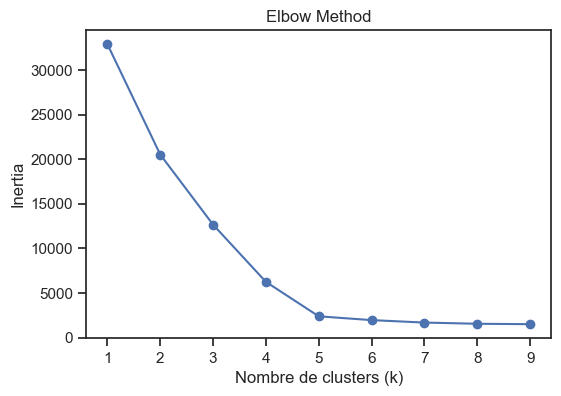

In [ ]:
inertia = []
K_range = range(1, 10)

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(6,4))
plt.plot(K_range, inertia, marker='o')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

Clustering KMeans

In [ ]:
k = 3  

kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Ajouter au dataframe original (aligner index)
df = df.loc[X.index]
df["Cluster"] = clusters

Analyse des clusters

In [ ]:
cluster_analysis = df.groupby("Cluster")[cols].mean()
print(cluster_analysis)

              Poids      Volume  Conductivite   Opacite  Rigidite
Cluster                                                          
0         22.508882   47.497369      0.000000  1.086853  3.049925
1         60.729504  120.161900      0.895555  1.281617  8.610169
2        203.447262  361.949684      0.001574  1.039529  9.130742


Visualisation PCA

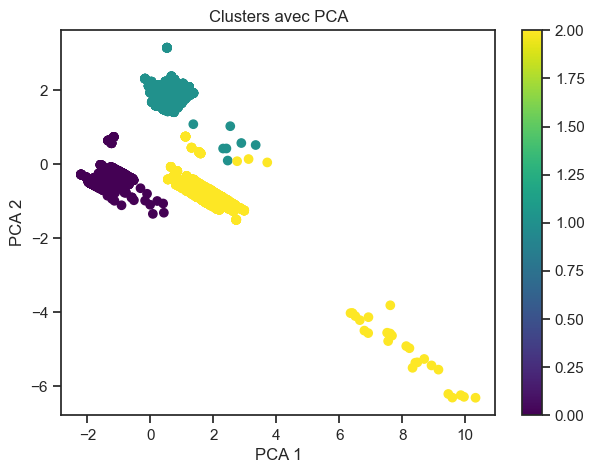

In [ ]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(7,5))
scatter = plt.scatter(X_pca[:,0], X_pca[:,1], c=clusters, cmap='viridis')
plt.title("Clusters avec PCA")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.colorbar(scatter)
plt.show()

Silhouette

In [ ]:
score = silhouette_score(X_scaled, clusters)
print("Silhouette Score :", score)

Silhouette Score : 0.7346943221018394


Comparaison avec vraie catégorie

In [ ]:
if "Categorie" in df.columns:
    print(pd.crosstab(df["Cluster"], df["Categorie"]))

Categorie  Métal  Papier  Plastique  Verre
Cluster                                   
0              0    1465       1714      0
1           1454       0          0      0
2              3       0          0   1620


In [ ]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# 1. Application du K-Means avec K=3 (selon votre coude)
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)
clusters = kmeans.fit_predict(df_final)

# 2. Ajout des clusters au DataFrame de base (les 8 variables)
df_subset['Cluster'] = clusters

print("Répartition des clients par cluster :")
print(df_subset['Cluster'].value_counts())

In [ ]:
from sklearn.cluster import KMeans

# 1. Configuration du K-Means (K=3 selon ton graphique du coude)
k_final = 3
kmeans = KMeans(n_clusters=k_final, random_state=42, n_init=10)

# 2. Apprentissage et prédiction sur le dataset NORMALISÉ
clusters = kmeans.fit_predict(df_final)

# 3. Ajout des clusters au DataFrame de base pour l'analyse humaine
df_subset['Cluster'] = clusters

print("Clustering terminé. Chaque client a désormais un numéro de groupe (0, 1 ou 2).")

In [ ]:
import matplotlib.pyplot as plt

# Compter le nombre de clients par cluster
counts = df_subset['Cluster'].value_counts().sort_index()

plt.figure(figsize=(8, 5))
plt.bar(counts.index.astype(str), counts.values, color=['#440154', '#21918c', '#fde725'])
plt.xlabel('Numéro du Cluster')
plt.ylabel('Nombre de clients')
plt.title('Répartition des clients par Segment')
plt.show()

In [ ]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# 1. On réduit les dimensions à 2 (PC1 et PC2) UNIQUEMENT pour l'affichage
pca_display = PCA(n_components=2)
components = pca_display.fit_transform(df_final)

# 2. On crée le graphique en utilisant les clusters calculés précédemment (sans PCA)
plt.figure(figsize=(10, 7))
scatter = plt.scatter(components[:, 0], components[:, 1], 
            c=clusters, # Ce sont tes clusters calculés sur df_final
            cmap='viridis', 
            alpha=0.6)

# 3. Habillage du graphique
plt.colorbar(scatter, label='Cluster')
plt.xlabel(f'Composante Principale 1 ({pca_display.explained_variance_ratio_[0]*100:.1f}%)')
plt.ylabel(f'Composante Principale 2 ({pca_display.explained_variance_ratio_[1]*100:.1f}%)')
plt.title('Représentation spatiale des Clusters (Projection PCA)')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

Visualisation

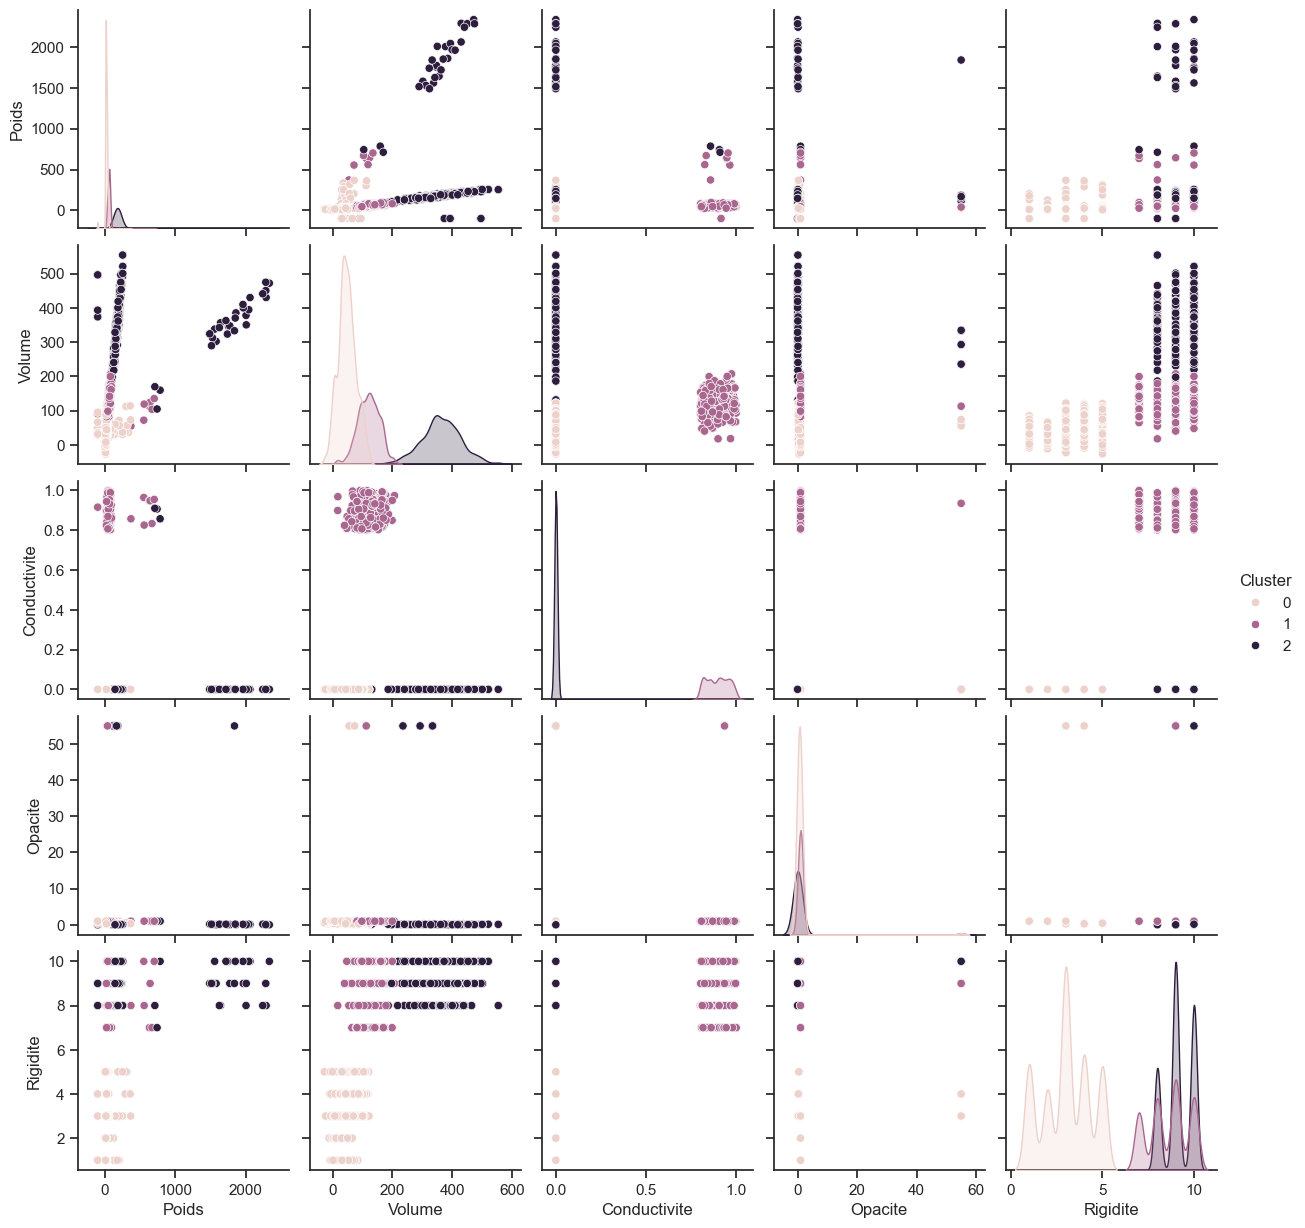

In [ ]:
sns.pairplot(df, hue="Cluster", vars=cols)
plt.show()

# nlp

In [ ]:
#Nettoyage du texte
import re

def clean_text(text):
    text = str(text).lower()  # minuscule
    text = re.sub(r'[^\w\s]', '', text)  # enlever ponctuation
    return text

df["clean_text"] = df["Rapport_Collecte"].apply(clean_text)

In [ ]:
#Étape 2 : Tokenization (découper en mots)
df["tokens"] = df["clean_text"].apply(lambda x: x.split())


In [ ]:
#Étape 3 : Supprimer les mots inutiles (stopwords)
from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS

def remove_stopwords(tokens):
    return [word for word in tokens if word not in ENGLISH_STOP_WORDS]

df["tokens"] = df["tokens"].apply(remove_stopwords)

In [ ]:
#Étape 4 : Stemming (optionnel) pour réduire les mots
from nltk.stem import PorterStemmer

stemmer = PorterStemmer()

df["tokens"] = df["tokens"].apply(lambda x: [stemmer.stem(word) for word in x])

In [ ]:

#TF-IDF
from sklearn.feature_extraction.text import TfidfVectorizer

tfidf = TfidfVectorizer()

X_text = tfidf.fit_transform(df["clean_text"])

In [ ]:
#Combiner avec ton dataset
import pandas as pd

X_text_df = pd.DataFrame(X_text.toarray(), columns=tfidf.get_feature_names_out())

df = pd.concat([df.reset_index(drop=True), X_text_df], axis=1)

In [ ]:
#Extraire volume
def extract_volume(text):
    match = re.search(r'(\d+)\s*L', str(text))
    return float(match.group(1)) if match else None

df["Volume_text"] = df["Rapport_Collecte"].apply(extract_volume)

In [ ]:

#Extraire catégorie
def detect_categorie(text):
    text = str(text).lower()
    if "plastique" in text:
        return "plastique"
    elif "verre" in text:
        return "verre"
    elif "papier" in text:
        return "papier"

In [ ]:

#Trouver les lignes intéressantes
df_nlp_useful = df[
    (df["Rapport_Collecte"].notna()) &
    (
        df["Volume"].isna() |
        df["Categorie"].isna() |
        df["Poids"].isna()
    )
]

print(df_nlp_useful.head())

In [ ]:

#Analyser le texte (voir s’il contient info)
for text in df_nlp_useful["Rapport_Collecte"].head(10):
    print(text)

In [ ]:

#Détecter volume dans texte
import re

df["has_volume_in_text"] = df["Rapport_Collecte"].apply(
    lambda x: bool(re.search(r'\d+\s*L', str(x)))
)

print(df["has_volume_in_text"].value_counts())

In [ ]:
#Détecter catégorie
def has_category(text):
    text = str(text).lower()
    return any(word in text for word in ["plastique", "verre", "papier"])

df["has_category_in_text"] = df["Rapport_Collecte"].apply(has_category)

In [ ]:

#Comparaison intelligente
df_test = df[
    (df["Volume"].isna()) &
    (df["has_volume_in_text"] == True)
]

print(len(df_test))

In [ ]:

#Volume
#Remplissage automatique depuis NLP
def extract_volume(text):
    match = re.search(r'(\d+)\s*L', str(text))
    return float(match.group(1)) if match else None

df["Volume_text"] = df["Rapport_Collecte"].apply(extract_volume)

df["Volume"] = df["Volume"].fillna(df["Volume_text"])

In [ ]:
#Catégorie
def detect_categorie(text):
    text = str(text).lower()
    if "plastique" in text:
        return "plastique"
    elif "verre" in text:
        return "verre"
    elif "papier" in text:
        return "papier"
    return None

df["Categorie"] = df["Categorie"].fillna(df["Rapport_Collecte"].apply(detect_categorie))

In [ ]:

#Vérifier si ça a amélioré
print(df.isnull().sum())